In [38]:
from pathlib import Path
import re
import pandas as pd

data_dir = Path("../data/raw/survey_data_2010_2024").resolve()
if not data_dir.exists():
    raise FileNotFoundError(
        f"Directory not found: {data_dir}\n"
        f"Current working directory: {Path.cwd()}"
    )

# Paste ZIP codes here as comma-separated values. Keep as strings to preserve leading zeros.
zip_codes_raw = """
11220,11232,11209,11231,11219,07305,10301,11228,07002,11252,11215,11218,10310,11245,11204,10041,10004,10304,11217,11241,11242,11202,10043,10305,11201,10006,10270,10005,10280,10271,10045,11243,07304,10277,10281,10038,10080,10008,11214,10313,10279,07311,07302,11238,10007,10090,10282,11226,10108,10117,10124,10125,10126,10129,10130,10131,10132,10133,10138,10156,10157,10159,10160,10163,10164,10185,10203,10211,10212,10213,10256,10258,10259,10260,10261,10265,10268,10269,10272,10273,10274,10275,10285,10286,11230,10278,10302,10013,11225,11205,07310,11251,07308,07303,07399,10002,07395,11223,11216,10012,11210,07201,11249,11213,10014,11203,07306,11224,10009,10276,10003,07030,10303,11206,10113,10249,10011,11211,11229,10242,10110,10010,07307,07114,10060,11233,11221,11212,07099,07105,07097,10314,07206,10118,10116,10001,10199,10016,10306,10121,10120,10119,11235,10122,10123,10311,11222,10018,11237,10158,11247,10178,10168,10165,07032,10174,11234,10166,10170,10173,11236,07087,10102,11109,10109,10114,10017,10175,10036,10169,10176,10167,10177,10179,10081,10087,10172,10171,11207,07086,10112,11120,10111,10020,10055,07029,10154,10152,10103,10101,10104,10150,10022,10019,07175,10105,10106,10107,07207,10151,10153,10155,07101,07184,07188,07189,07191,07192,07193,07195,07198,07199,07102,07094,11101,10308,07202,11378,10065,10044,10023,11239,11104,10069,07108,10021,07112,11385,07208,11208,07093,10162,10075,07103,07096,11106,10024,11256,10028,07047,11379,11377,07205,11697,07104,07071,07031,10128,10312,11102,11103,11421,11695,11416,07107,11414,07036,11417,11373,07111,07008,11374,10025,11372,10029,07203,07106,07109,11370,11105,07019,07018,07204,10026,10035,07022,07017,11694,07073,10115,07083,11418,11375,07010,11369,11415,11419,10027,11420,07072,11693,10309,11368,07070,07657,07020,11424,10037,07065,07001,11371,10454,07064,07051,10030,11367,07077,07050,07079,07033,07074,07040,07088,11435,07110,07003,11405,11425,11499,10031,07643,07014,10451,11436,11431,10455,10039,07016,07028,10474,10032,11351,07650,11355,11430,11451,11692,07075,07660,07608,11352,11354,07042,07041,11433,11432,11356,07024,07057,11439,10456,10307,07066,07699,10452,11386,07027,11434,10459,07095,11366,07604,07067,07606,11365,07055,07012,07052,07605,11437,10473,08861,07081,11380,08830,07734,11690,08862,11358,10033,11412,07603,11691,07015,10040,11423,10457,11357,10472,10453,07043,07090,11096,07644,07758,11413,07091,07026,10460,08863,07078,07044,07602,07601,07718,11422,07011,10034,07666,07092,11361,11427,07013,10462,11411,11364,11360,11429,07735,07076,11428,07632,07737,07631,10468,07021,07901,07009,07999,07902,08832,10458,11516,10461,11359,07730,07607,10463,11509,10465,07039,07662,08840,08879,08820,11559,07752,07007,07716,07663,11581,07732,11598,07503,07023,07407,11582,07721,07068,11426,11362,11363,10467,07748,11580,07424,11003,07513,08837,10469,07504,11557,11001,11002,07006,07062,10471,11022,11004,07621,07670,07061,07974,07661,07501,11005,08859,10475,10464,07928,10470,11021,07799,11023,07509,07510,07511,07533,07543,07544,07646,07505,11020,07514,07512,07922,07760,10466,08818,11042,11563,07747,11024,11565,07502,07522,11010,07410,07080,10705,11518,07060,07524,07652,07653,07004,07733,07932,11040,07936,07704,07626,07628,08817,07701,07069,10702,10550,07940,07538,08872,11558,07649,07063,10704,10551,11552,07507,08871,08855,11030,10553,07058,07627,07641,11570,10803,11571,08899,11572,07452,11531,11561,07506,07935,10805,07739,07738,07508,10552,07630,07620,11530,07474,07750,07961,07624,11507,11501,10701,08882,11596,11050,07933,08904,07702,10802,11550,07470,07451,11551,10708,07981,10801,10703,07450,08854,07703,11510,08812,07751,07676,07035,07976,11577,07054,11576,08857,07980,07034,07757,07765,08901,07640,11549,11514,08906,07946,11599,07423,07440,11569,11555,10710,07648,07432,08903,08933,08989,11553,08846,11575,07927,10709,10707,11520,07059,07642,08816,07082,07045,11547,07481,10804,11548,07675,07962,07963,10538,11556,07724,07740,11579,07960,10706,07647,08850,07764,07463,08884,11590,10964,07444,11568,07746,11566,07677,07722,11554,07417,08880,08805,10543,10983,07046,07656,10522,07401,07950,07939,10976,08836,10583,11545,11710,10502,07755,11542,07920,07878,07442,08902,08873,07457,07458,10503,08828,07005,07436,10968,07938,07645,07723,10962,07834,10530,07712,11753,11793,11756,10965,11853,10528,11560,11802,10533,11801,07446,07711,08890,07405,07924,07926,10606,10913,11783,07420,10580,11815,10605,10607,08835,08831,07970,08875,07763,07945,07465,11714,10601,08807,07430,11765,07753,10602,10610,11758,07756,10523,08810,10954,10960,07726,07869,07801,11791,11775,07978,08824,08823,10994,11709,11773,07754,07720,07802,11771,07866,10603,11803,10591,08869,07842,11762,10577,10982,08852,07495,07977,10977,07717,11804,07728,07710,11737,07727,10573,10952,07806,11797,10604,07845,11735,07715,07803,10595,10989,10532,10931,07921,11701,07934,10901,07719,08876,06836,07456,07931,07885,07847,08512,11724,11726,07480,07930,08821,07762,07876,06830,10956,11747,10594,08844,08502,08528,10570,08720,07731,11757,10974,10920,10510,08553,07856,06831,07979,08536,07435,07852,08750,06878,11704,08858,08535,07438,06870,11798,10545,07849,11743,11702,08888,08870,07850,07836,08730,07857,08558,08510,11707,08542,10923,11703,08504,06904,06911,06912,06913,06914,06926,06927,10984,08541,08543,08544,06901,08724,06902,10562,07421,10514,11729,10993,11740,11721,10979,10520,07460,08550,08742,08561,08887,11795,10987,07830,10546,06905,07874,06906,07828,08833,07871,07853,10925,10975,10521,11731,08701,07439,10980,08691,10548,06907,07870,08527,11718,10549,11768,06903,11706,08526,06820,10596,08885,08723,11725,08525,07422,10511,07416,11717,07821,10506,06853,07840,08514,08690,10910,10986,08738,08648,10912,07462,10507,08551,07428,07820,08822,07419,11751,10566,08501,08801,06854,08829,10959,10567,08619,10990,07879,11754,08739,10926,08826,10911,08534,06840,11788,11722,07848,10517,06850,07865,10598,08755,10576,06855,08533,08809,08733,07839,11752,11787,11730,08638,06852,06856,06857,06858,06860,07418,10928,10536,08735,08620,07880,08753,10950,08629,10547,08609,10917,10501,11770,11749,11739,10922,08868,07831,10949,08601,08602,08603,08604,08605,08606,08607,08645,08646,08647,08666,08695,08610,06851,08618,07822,10981,08515,08650,10537,10588,08608,07838,11780,08625,10518,10527,11769,08757,08628,08827,07860,08560,07846,10921,08751,08867,08530,10587,10526,10535,08611,08754,08756,11716,10930,08557,11767,10590,10589,07863,10918,06881,06888,06889,08732,10540,10969,10578,06880,06897,11796,08511,11779
"""

target_zips = {
    z.strip().zfill(5)
    for z in zip_codes_raw.replace("\n", ",").split(",")
    if z.strip()
}

# Pattern: subset_YYYYW (year/wave used only to identify file groups)
name_pattern = re.compile(r"^(catch|trip|size)_(\d{4})(\d)$", flags=re.IGNORECASE)

def read_file(path: Path) -> pd.DataFrame:
    ext = path.suffix.lower()
    if ext == ".csv":
        return pd.read_csv(path, low_memory=False)
    if ext in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if ext == ".parquet":
        return pd.read_parquet(path)
    raise ValueError(f"Unsupported file type: {path.name}")

def normalize_id(series: pd.Series) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .str.replace(r"\.0+$", "", regex=True)
    )

def normalize_zip(series: pd.Series) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .str.replace(r"\.0+$", "", regex=True)
        .str.zfill(5)
    )

def first_non_null(series: pd.Series):
    s = series.dropna()
    return s.iloc[0] if not s.empty else pd.NA

def collapse_to_one_row_per_id(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    if "ID_CODE" not in df.columns:
        return pd.DataFrame(columns=["ID_CODE"])
    df = df.dropna(subset=["ID_CODE"]).copy()
    return df.groupby("ID_CODE", as_index=False).agg(first_non_null)

valid_files = []
for path in sorted(data_dir.iterdir()):
    if not path.is_file():
        continue
    match = name_pattern.match(path.stem)
    if not match:
        continue
    subset = match.group(1).lower()
    valid_files.append((path, subset))

trip_parts = []
for path, subset in valid_files:
    if subset != "trip":
        continue
    df = read_file(path)
    if "ID_CODE" not in df.columns or "ZIP" not in df.columns:
        continue
    df["ID_CODE"] = normalize_id(df["ID_CODE"])
    df["ZIP"] = normalize_zip(df["ZIP"])
    df = df[df["ZIP"].isin(target_zips)].copy()
    if not df.empty:
        trip_parts.append(df)

if not trip_parts:
    raise ValueError("No trip rows matched your ZIP list. Check ZIP values and formats.")

trip_all = pd.concat(trip_parts, ignore_index=True, sort=False)
allowed_id_codes = set(trip_all["ID_CODE"].dropna().unique())

catch_parts = []
size_parts = []
for path, subset in valid_files:
    if subset not in {"catch", "size"}:
        continue
    df = read_file(path)
    if "ID_CODE" not in df.columns:
        continue
    df["ID_CODE"] = normalize_id(df["ID_CODE"])
    df = df[df["ID_CODE"].isin(allowed_id_codes)].copy()
    if df.empty:
        continue
    if subset == "catch":
        catch_parts.append(df)
    else:
        size_parts.append(df)

catch_all = pd.concat(catch_parts, ignore_index=True, sort=False) if catch_parts else pd.DataFrame(columns=["ID_CODE"])
size_all = pd.concat(size_parts, ignore_index=True, sort=False) if size_parts else pd.DataFrame(columns=["ID_CODE"])

# Ignore year/wave: collapse each subset to one row per ID_CODE using first non-null values
trip_one = collapse_to_one_row_per_id(trip_all)
catch_one = collapse_to_one_row_per_id(catch_all)
size_one = collapse_to_one_row_per_id(size_all)

df_survey = trip_one.merge(catch_one, on="ID_CODE", how="left", suffixes=("", "_catch"))
df_survey = df_survey.merge(size_one, on="ID_CODE", how="left", suffixes=("", "_size"))

print(f"Using directory: {data_dir}")
print(f"Target ZIP count: {len(target_zips)}")
print(f"Trip rows kept after ZIP filter: {len(trip_all)}")
print(f"Unique ID_CODE kept: {len(allowed_id_codes)}")
print(f"Final shape: {df_survey.shape}")
df_survey.head()

Using directory: C:\Users\ross9\GitHub\fishing-predictor\data\raw\survey_data_2010_2024
Target ZIP count: 1074
Trip rows kept after ZIP filter: 97347
Unique ID_CODE kept: 90823
Final shape: (90823, 147)


,ID_CODE,PRIM2_COMMON,PRIM1_COMMON,STRAT_ID,PSU_ID,YEAR,REG_RES,ST_RES,CNTY_RES,ST,CNTY,INTSITE,MODE_F,MODE_FX,AREA,AREA_X,HRSF,ADD_HRS,FFDAYS12,FFDAYS2,TELEFON,CNTRBTRS,NUM_TYP2,NUM_TYP3,NUM_TYP4,NUM_TYP6,PARTY,FIRST,SUB_REG,WAVE,CATCH,ON_LIST,NUM_TYP9,BOAT_HRS,COASTAL,NEW_LIST,ASG_CODE,MODE_ASG,MONTH,KOD,PRT_CODE,CELLTYPE,FSHINSP_A,NUM_FISH_A,COUNTY,TSN1,TSN2,TIME,DISTKEYS,GEAR,PVT_RES,SEP_FISH,ADD_PH,F_BY_P,RIG,HRS_DTD,LICENSE,DATE1,DIST,PRIM1,PRIM2,MODE2001,AREA_NC,MONITOR,COMPFLAG,AGE,ART_REEF,REEFCODE,SEX,TOURN,TURTLE,MUNI_RES,MUNI_TRP,WP_INT,VAR_ID,ARX_METHOD,ALT_FLAG,LEADER,FL_REG,ZIP,DATE_PUBLISHED,REGION,STRAT_INTERVAL,REEF,IMP_REC,COMMON,STRAT_ID_catch,PSU_ID_catch,YEAR_catch,ST_catch,MODE_FX_catch,AREA_X_catch,SUB_REG_catch,WAVE_catch,MONTH_catch,KOD_catch,SP_CODE,CLAIM,RELEASE,HARVEST,CLAIM_UNADJ,HARVEST_UNADJ,RELEASE_UNADJ,TOT_LEN_A,WGT_A,TOT_LEN_B1,WGT_B1,TOT_CAT,WGT_AB1,TOT_LEN,LANDING,VAR_ID_catch,ARX_METHOD_catch,ALT_FLAG_catch,FL_REG_catch,WP_CATCH_PRECAL,WP_INT_catch,WP_CATCH,DATE_PUBLISHED_catch,REGION_catch,STRAT_INTERVAL_catch,IMP_REC_catch,YEAR_size,ST_size,MODE_FX_size,AREA_X_size,SUB_REG_size,WAVE_size,MONTH_size,KOD_size,SP_CODE_size,LNGTH,WGT,LNGTH_IMP,WGT_IMP,STRAT_ID_size,PSU_ID_size,COMMON_size,WGT_UNADJ,WP_SIZE,L_IN_BIN,L_CM_BIN,VAR_ID_size,ARX_METHOD_size,ALT_FLAG_size,DATE_PUBLISHED_size,IMP_REC_size
0,1000920100110029,<NA>,SPOTTED SEATROUT,201017128301we,1000920100110101327,2010,5.0,34.0,3.0,12,101.0,327.0,5.0,3,5,5.0,2.0,0.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,<NA>,<NA>,7,1,2.0,<NA>,<NA>,<NA>,O,<NA>,1.000920e+12,<NA>,1.0,we,1000920100110029,<NA>,<NA>,<NA>,BERGEN,169239.0,<NA>,1731.0,8.0,1.0,1.0,8.0,1.0,8.0,<NA>,<NA>,1.0,19FEB201014:48,8.0,8835440102.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1520.660135,201017128301we,<NA>,0.0,1000920100110029,8.0,07663,03/03/2025,<NA>,<NA>,<NA>,<NA>,<NA>,201017128301we,1000920100110101327,2010,12,3,5,7,1,1,we,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,201017128301we,<NA>,0.0,8.0,307.667853,1520.660135,1520.660135,03/03/2025,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000920100318002,<NA>,SPOTTED SEATROUT,201027128703wd,1000920100318101899,2010,5.0,36.0,103.0,12,101.0,899.0,8.0,7,2,5.0,5.0,0.0,23.0,7.0,1.0,1.0,1.0,0.0,0.0,1.0,2.0,2.0,7,2,2.0,<NA>,<NA>,<NA>,O,<NA>,1.000920e+12,<NA>,3.0,wd,1000920100318001,1.0,<NA>,<NA>,SUFFOLK,169239.0,<NA>,1409.0,8.0,1.0,1.0,8.0,1.0,8.0,<NA>,<NA>,1.0,22APR201008:01,8.0,8835440102.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1147.471854,201027128703wd,<NA>,0.0,1000920100318002,8.0,11767,03/03/2025,<NA>,<NA>,<NA>,<NA>,SPOTTED SEATROUT,201027128703wd,1000920100318101899,2010,12,7,5,7,2,3,wd,8835440102.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,201027128703wd,<NA>,0.0,8.0,304.145583,1147.471854,1147.471854,03/03/2025,<NA>,<NA>,<NA>,2010.0,12.0,7.0,5.0,7.0,2.0,3.0,wd,<NA>,<NA>,<NA>,0.0,0.0,201027128703wd,1000920100318101899,<NA>,<NA>,1147.471854,<NA>,<NA>,201027128703wd,<NA>,0.0,03/03/2025,<NA>
2,1000920100407007,<NA>,<NA>,201027128304wd,100092010040757544,2010,5.0,36.0,103.0,12,57.0,544.0,5.0,3,K,5.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,<NA>,<NA>,7,2,2.0,<NA>,<NA>,<NA>,O,<NA>,1.000920e+12,<NA>,4.0,wd,1000920100407007,<NA>,<NA>,<NA>,SUFFOLK,<NA>,<NA>,1459.0,8.0,1.0,1.0,8.0,2.0,8.0,<NA>,<NA>,2.0,21MAY201009:13,8.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2070.577685,201027128304wd,<NA>,0.0,1000920100407007,8.0,11717,03/03/2025,<NA>,<NA>,<NA>,<NA>,<NA>,201027128304wd,100092010040757544,2010,12,3,5,7,2,4,wd,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,201027128304wd,<NA>,0.0,8.0,603.274552,2070.577685,2070.577685,03/03/2025,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1000920100717006,<NA>,<NA>,201047128307we,100092010071781632,2010,5.0,36.0,85.0,12,81.0,632.0,1.0,3,K,

In [39]:
pd.set_option("display.max_columns", None)

def print_summary(df: pd.DataFrame):
    df.head(100)
    print("Null counts per column:")
    print(df.isna().sum())

    print("\nData types and non-null counts:")
    print(df.info())

    print("\nSummary statistics for numeric columns:")
    print(df.describe())

print_summary(df_survey)

Null counts per column:
ID_CODE                    0
PRIM2_COMMON           65182
PRIM1_COMMON           12887
STRAT_ID                   0
PSU_ID                     0
                       ...  
VAR_ID_size            11370
ARX_METHOD_size        90823
ALT_FLAG_size          11370
DATE_PUBLISHED_size    11370
IMP_REC_size           85365
Length: 147, dtype: int64

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90823 entries, 0 to 90822
Columns: 147 entries, ID_CODE to IMP_REC_size
dtypes: float64(48), int64(11), object(86), string(2)
memory usage: 101.9+ MB
None

Summary statistics for numeric columns:
               YEAR            ST          CNTY       INTSITE        MODE_F  \
count  90823.000000  90823.000000  90823.000000  90823.000000  90823.000000   
mean    2017.758585     33.599749     61.519120    660.460555      6.121313   
std        4.307432      6.732159     54.912656   1132.022811      2.223123   
min     2010.000000      1.000000   

In [40]:
for col in df_survey.columns:
    print(col)

ID_CODE
PRIM2_COMMON
PRIM1_COMMON
STRAT_ID
PSU_ID
YEAR
REG_RES
ST_RES
CNTY_RES
ST
CNTY
INTSITE
MODE_F
MODE_FX
AREA
AREA_X
HRSF
ADD_HRS
FFDAYS12
FFDAYS2
TELEFON
CNTRBTRS
NUM_TYP2
NUM_TYP3
NUM_TYP4
NUM_TYP6
PARTY
FIRST
SUB_REG
WAVE
CATCH
ON_LIST
NUM_TYP9
BOAT_HRS
COASTAL
NEW_LIST
ASG_CODE
MODE_ASG
MONTH
KOD
PRT_CODE
CELLTYPE
FSHINSP_A
NUM_FISH_A
COUNTY
TSN1
TSN2
TIME
DISTKEYS
GEAR
PVT_RES
SEP_FISH
ADD_PH
F_BY_P
RIG
HRS_DTD
LICENSE
DATE1
DIST
PRIM1
PRIM2
MODE2001
AREA_NC
MONITOR
COMPFLAG
AGE
ART_REEF
REEFCODE
SEX
TOURN
TURTLE
MUNI_RES
MUNI_TRP
WP_INT
VAR_ID
ARX_METHOD
ALT_FLAG
LEADER
FL_REG
ZIP
DATE_PUBLISHED
REGION
STRAT_INTERVAL
REEF
IMP_REC
COMMON
STRAT_ID_catch
PSU_ID_catch
YEAR_catch
ST_catch
MODE_FX_catch
AREA_X_catch
SUB_REG_catch
WAVE_catch
MONTH_catch
KOD_catch
SP_CODE
CLAIM
RELEASE
HARVEST
CLAIM_UNADJ
HARVEST_UNADJ
RELEASE_UNADJ
TOT_LEN_A
WGT_A
TOT_LEN_B1
WGT_B1
TOT_CAT
WGT_AB1
TOT_LEN
LANDING
VAR_ID_catch
ARX_METHOD_catch
ALT_FLAG_catch
FL_REG_catch
WP_CATCH_PRECAL
WP_INT_catch

In [41]:
#dropping the columns I know I won't need
df_survey = df_survey[[ "ID_CODE", "PRIM1_COMMON", "PRIM2_COMMON", "PSU_ID", "AREA_X", "CATCH", "DIST", "DISTKEYS", "F_BY_P", "FFDAYS12", "FFDAYS2", "FSHINSP_A", "GEAR", "HRSF", "KOD", "MODE_F", "MODE_FX", "MODE2001", "NUM_FISH_A", "TIME", "TSN1", "TSN2", "CNTRBTRS"]]
print(df_survey.head(100))
for col in df_survey.columns:
    print(col)

             ID_CODE      PRIM1_COMMON PRIM2_COMMON               PSU_ID  \
0   1000920100110029  SPOTTED SEATROUT         <NA>  1000920100110101327   
1   1000920100318002  SPOTTED SEATROUT         <NA>  1000920100318101899   
2   1000920100407007              <NA>         <NA>   100092010040757544   
3   1000920100717006              <NA>         <NA>   100092010071781632   
4   1000920100717007              <NA>         <NA>   100092010071781632   
..               ...               ...          ...                  ...   
95  1103320120825008              <NA>         <NA>   110332012082531434   
96  1103320120922004              SCUP         <NA>  1103320120922119603   
97  1103320120922005              SCUP         <NA>  1103320120922119603   
98  1103320120922007          BLUEFISH         SCUP  1103320120922119603   
99  1103320120922008          BLUEFISH         SCUP  1103320120922119603   

    AREA_X  CATCH  DIST DISTKEYS  F_BY_P  FFDAYS12  FFDAYS2 FSHINSP_A  GEAR  \
0      5

In [42]:
print_summary(df_survey)

Null counts per column:
ID_CODE             0
PRIM1_COMMON    12887
PRIM2_COMMON    65182
PSU_ID              0
AREA_X              0
CATCH               0
DIST                0
DISTKEYS        88464
F_BY_P              0
FFDAYS12            0
FFDAYS2             0
FSHINSP_A       59841
GEAR                0
HRSF               76
KOD                 1
MODE_F              0
MODE_FX             0
MODE2001         2359
NUM_FISH_A      59841
TIME                0
TSN1            13883
TSN2            71089
CNTRBTRS            0
dtype: int64

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90823 entries, 0 to 90822
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID_CODE       90823 non-null  string 
 1   PRIM1_COMMON  77936 non-null  object 
 2   PRIM2_COMMON  25641 non-null  object 
 3   PSU_ID        90823 non-null  object 
 4   AREA_X        90823 non-null  float64
 5   CATCH    

Missing columns (skipped): ['MODE2001', 'GEAR']


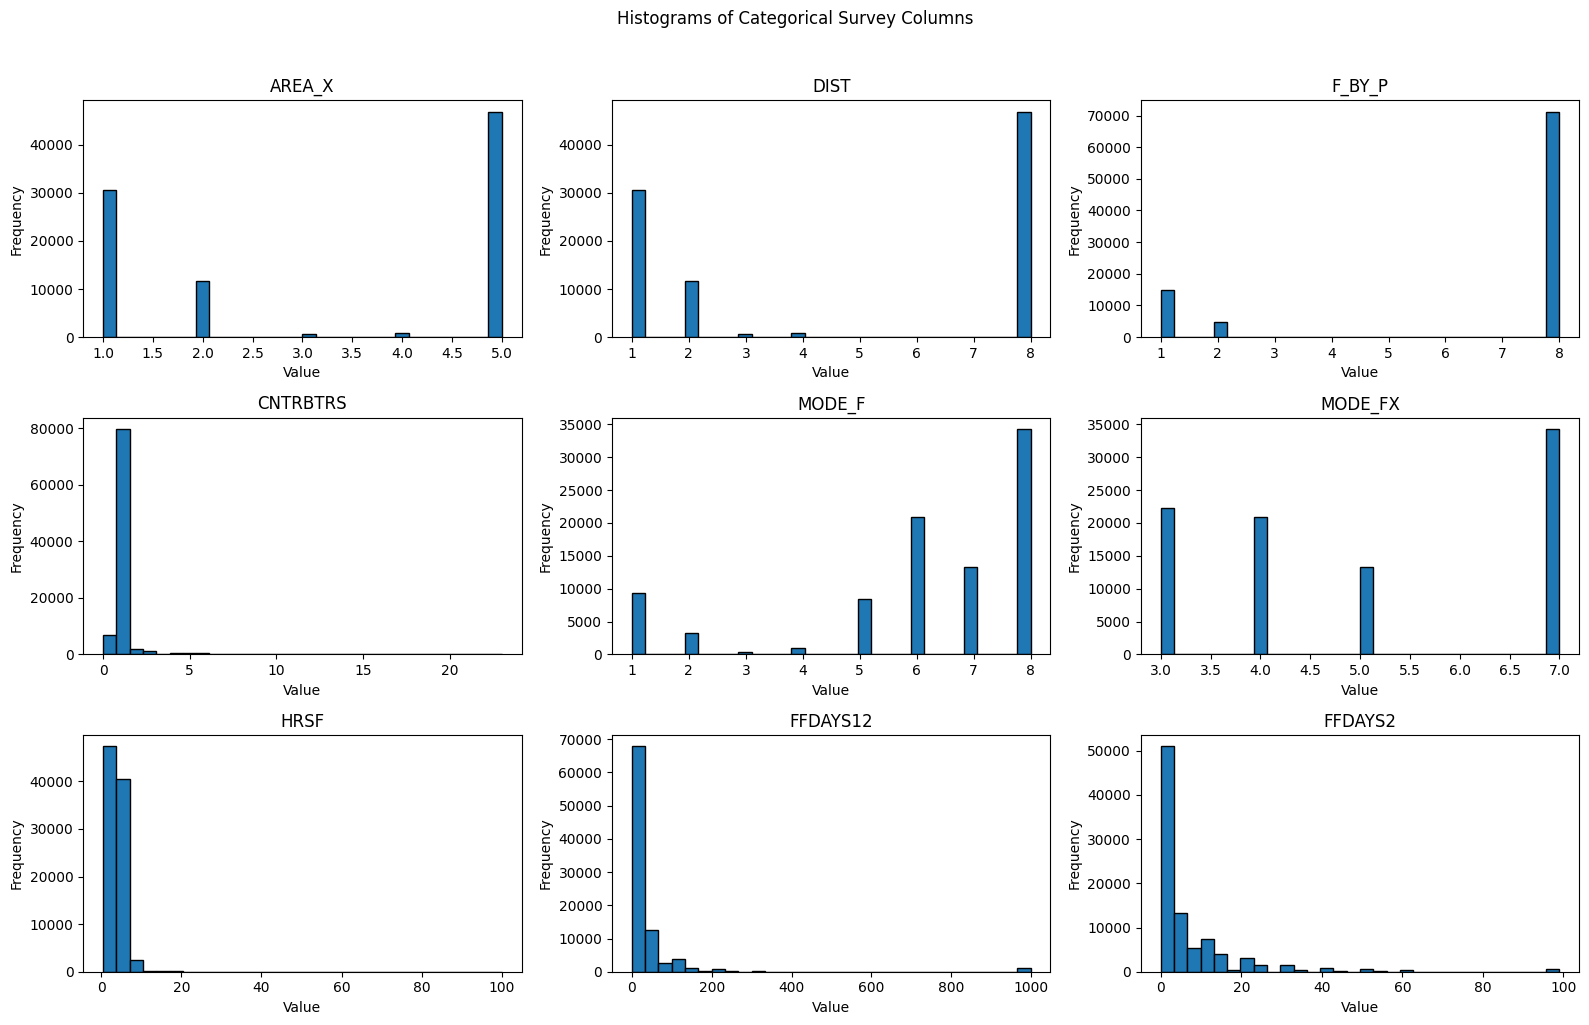

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

hist_cols = [
    "AREA_X",
    "DIST",
    "F_BY_P",
    "CNTRBTRS",
    "MODE_F",
    "MODE_FX",
    "MODE2001",
    "GEAR",
    "HRSF",
    "FFDAYS12",
    "FFDAYS2",
]

missing_cols = [c for c in hist_cols if c not in df_survey.columns]
if missing_cols:
    print("Missing columns (skipped):", missing_cols)

plot_cols = [c for c in hist_cols if c in df_survey.columns]
if not plot_cols:
    raise ValueError("None of the requested histogram columns exist in df_survey")

plot_df = df_survey[plot_cols].copy()
for c in plot_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

axes = plot_df.hist(
    bins=30,
    figsize=(16, 10),
    layout=(3, 3),
    edgecolor="black",
    grid=False,
 )

for ax in axes.flatten():
    if ax is not None:
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

plt.suptitle("Histograms of Categorical Survey Columns", y=1.02)
plt.tight_layout()
plt.show()

## Takeaways for Categorical Features

- **Gear** is negligible — almost all participants were fishing with hook on line.
- **Hours fished** does contains negligable amount of unknowns (value of 99). Unknowns can be imputed or dropped.
- Need to decide between:
  - **Exact mode** (specifying the type of shore structure), or
  - **Collapsed mode** (grouped categories)  
  Exact mode may lead to overfitting but could provide more detailed insight into fishing methods.
- Uncertainty about whether to average catch based on **contributors** to total catch.
- Unsure if **area** and **distance** variables may be collinear.
- **Fish by person** may be irrelevant.

In [ ]:
df_survey = df_survey.drop(columns=["PRIM2_COMMON", "GEAR", "MODE2001", "DISTKEYS"])
print_summary(df_survey)

Null counts per column:
ID_CODE             0
PRIM1_COMMON    12887
PSU_ID              0
AREA_X              0
CATCH               0
DIST                0
DISTKEYS        88464
F_BY_P              0
FFDAYS12            0
FFDAYS2             0
FSHINSP_A       59841
HRSF               76
KOD                 1
MODE_F              0
MODE_FX             0
NUM_FISH_A      59841
TIME                0
TSN1            13883
TSN2            71089
CNTRBTRS            0
dtype: int64

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90823 entries, 0 to 90822
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID_CODE       90823 non-null  string 
 1   PRIM1_COMMON  77936 non-null  object 
 2   PSU_ID        90823 non-null  object 
 3   AREA_X        90823 non-null  float64
 4   CATCH         90823 non-null  float64
 5   DIST          90823 non-null  float64
 6   DISTKEYS      2359 non-null   ob